#### 손가락 숫자 모양의 Image 분류

##### Data 불러오기

In [72]:
import glob
from PIL import Image
import matplotlib.pyplot as plt

In [73]:
train_images = glob.glob("../Data/fingers/train/*.png")
test_images = glob.glob("../Data/fingers/test/*.png")

In [74]:
# file name 확인
train_images[:5]

['../Data/fingers/train\\00048bba-979b-4f84-b833-5bbbb082b582_0L.png',
 '../Data/fingers/train\\000547a2-d456-4b16-b351-12ca9b40e390_0L.png',
 '../Data/fingers/train\\000cac8e-fcf0-4f8c-bd16-c257d1e6d7a8_2L.png',
 '../Data/fingers/train\\000d9961-8136-4dee-9820-86e178777958_0L.png',
 '../Data/fingers/train\\0010095b-2e3d-4517-a511-1f688c378f96_5L.png']

In [75]:
# 갯수 확인
print(len(train_images))
print(len(test_images))

18000
3600


In [76]:
# train data와 test data 만들기 : 128*128 -> 32*32

train_input = []
train_target = []
test_input = []
test_target = []

# train data
for image in sorted(train_images):
    img = Image.open(image)
    imgResize = img.resize((32, 32), Image.Resampling.LANCZOS)
    train_input.append(imgResize)
    train_target.append(image[-6:-4])

# test data
for image in sorted(test_images):
    img = Image.open(image)
    imgResize = img.resize((32, 32), Image.Resampling.LANCZOS)
    test_input.append(imgResize)
    test_target.append(image[-6:-4])

In [77]:
# Target Data확인
print(train_target[:5])
print(test_target[:5])

['0L', '0L', '2L', '0L', '5L']
['5L', '5L', '3R', '5L', '5L']


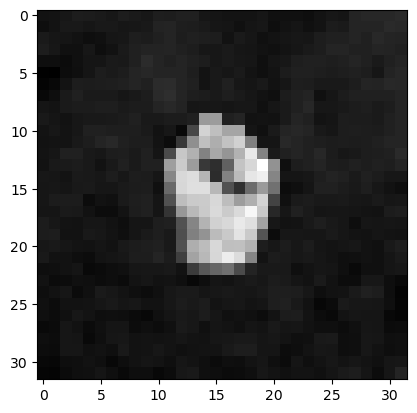

In [78]:
# train의 이미지 확인
plt.imshow(train_input[0], cmap='gray')
plt.show()

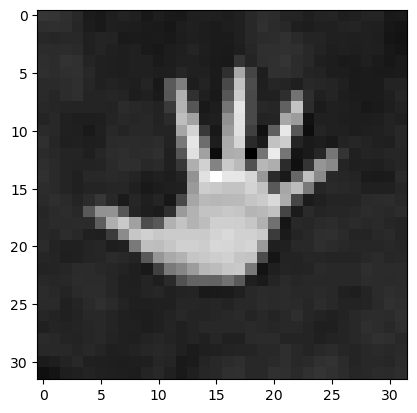

In [79]:
# train의 이미지 확인
plt.imshow(test_input[0], cmap='gray')
plt.show()

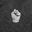

In [80]:
train_input[0]

#### numpy배열로 변경

In [81]:
import numpy as np

In [82]:
# train Data 만들기(18000 * 32 * 32)
tempData = np.zeros(
    18000 * 32 * 32,
    dtype=np.int32
).reshape(18000, 32, 32)


i = 0
for image in train_input:
    img = np.array(image, dtype=np.int32)
    tempData[i,:,:] = img
    i+=1

train_input = tempData.copy()

In [83]:
# test Data 만들기(3600 * 32 * 32)
tempData = np.zeros(
    3600 * 32 * 32,
    dtype=np.int32
).reshape(3600, 32, 32)


i = 0
for image in test_input:
    img = np.array(image, dtype=np.int32)
    tempData[i,:,:] = img
    i+=1

test_input = tempData.copy()

In [84]:
# 배열크기 확인
print(train_input.shape)
print(test_input.shape)

(18000, 32, 32)
(3600, 32, 32)


In [85]:
train_input[0]

array([[51, 52, 55, ..., 66, 66, 68],
       [48, 52, 56, ..., 64, 68, 67],
       [57, 54, 53, ..., 67, 65, 63],
       ...,
       [47, 46, 54, ..., 51, 48, 50],
       [44, 43, 48, ..., 50, 54, 55],
       [42, 41, 46, ..., 47, 54, 64]], shape=(32, 32), dtype=int32)

----
#### Target을 숫자로 변경하기

In [86]:
label_to_int = {
    '0R' : 0,
    '1R' : 1,
    '2R' : 2,
    '3R' : 3,
    '4R' : 4,
    '5R' : 5,
    '0L' : 6,
    '1L' : 7,
    '2L' : 8,
    '3L' : 9,
    '4L' : 10,
    '5L' : 11
}

In [87]:
# Train target 숫자로 변경
temp = []
for label in train_target:
    temp.append(label_to_int[label])
train_target = temp.copy()

In [88]:
# Test target 숫자로 변경
temp = []
for label in test_target:
    temp.append(label_to_int[label])
test_target = temp.copy()

In [89]:
train_target[:5]

[6, 6, 8, 6, 11]

In [90]:
test_target[:5]

[11, 11, 3, 11, 11]

In [91]:
# Target도 numpy배열로 변경
train_target = np.array(train_target)
test_target = np.array(test_target)

print(train_target[:5])
print(test_target[:5])

[ 6  6  8  6 11]
[11 11  3 11 11]


#### Deep Learning 구성하기

In [92]:
from sklearn.model_selection import train_test_split
from tensorflow import keras

In [93]:
train_scaled = (train_input / 255.0)
test_scaled = (test_input / 255.0)
train_scaled

array([[[0.2       , 0.20392157, 0.21568627, ..., 0.25882353,
         0.25882353, 0.26666667],
        [0.18823529, 0.20392157, 0.21960784, ..., 0.25098039,
         0.26666667, 0.2627451 ],
        [0.22352941, 0.21176471, 0.20784314, ..., 0.2627451 ,
         0.25490196, 0.24705882],
        ...,
        [0.18431373, 0.18039216, 0.21176471, ..., 0.2       ,
         0.18823529, 0.19607843],
        [0.17254902, 0.16862745, 0.18823529, ..., 0.19607843,
         0.21176471, 0.21568627],
        [0.16470588, 0.16078431, 0.18039216, ..., 0.18431373,
         0.21176471, 0.25098039]],

       [[0.18823529, 0.17254902, 0.17647059, ..., 0.21960784,
         0.21176471, 0.21176471],
        [0.16862745, 0.18039216, 0.17254902, ..., 0.21176471,
         0.19215686, 0.19607843],
        [0.20392157, 0.17647059, 0.16862745, ..., 0.20392157,
         0.19607843, 0.2       ],
        ...,
        [0.21568627, 0.22745098, 0.20784314, ..., 0.19215686,
         0.19215686, 0.20392157],
        [0.2

In [94]:
train_scaled, val_scaled, train_target, val_target = \
    train_test_split(
        train_scaled,
        train_target,
        test_size=0.2,
        random_state=42
    )


In [159]:
model = keras.Sequential()
model.add(keras.layers.Flatten(input_shape=(32, 32)))
model.add(keras.layers.Dense(100, activation='relu', input_shape=(784,), name='hidden'))
model.add(keras.layers.Dense(50, activation='relu'))
model.add(keras.layers.Dense(30, activation='relu'))
model.add(keras.layers.Dense(12, activation='softmax', name='output'))

In [160]:
model.summary()

Model: "sequential_24"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_22 (Flatten)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden (Dense)                  │ (None, 100)            │       102,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 30)             │         1,530 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 12)             │           372 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,452 (427.55 KB)

 Trainable params: 109,452 (427.55 KB)

 Non-trainable params: 0 (0.00 B)

In [161]:
# 손실함수
model.compile(
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)
# 학습하기
model.fit(
    train_scaled,
    train_target,
    epochs=20
    )

Epoch 1/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6950 - loss: 1.0237
Epoch 2/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9303 - loss: 0.2275
Epoch 3/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9650 - loss: 0.1161
Epoch 4/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9779 - loss: 0.0716
Epoch 5/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9837 - loss: 0.0532
Epoch 6/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9847 - loss: 0.0469
Epoch 7/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9889 - loss: 0.0345
Epoch 8/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9899 - loss: 0.0305
Epoch 9/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9919 - loss: 0.0269
Epoch 10/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9931 - loss: 0.0240
Epoch 11/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9923 - loss: 0.0289
Epoch 12/20
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step

In [162]:
score_train = model.evaluate(train_scaled, train_target)
score_val = model.evaluate(val_scaled, val_target)
score_test = model.evaluate(test_scaled, test_target)


print("train acc =", score_train[1])
print("val acc =", score_val[1])
print("test acc =", score_test[1])

450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 983us/step - accuracy: 0.9999 - loss: 3.9333e-04
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9994 - loss: 0.0011   
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9986 - loss: 0.0040  
train acc = 0.9999305605888367
val acc = 0.9994444251060486
test acc = 0.9986110925674438


In [ ]:
# test가 더 좋으면 안된다.
# epoch 5 -> 0.995, 0.993, 0.991
# epoch 7 -> 0.998, 0.998, 0.995

# epoch 10 -> 0.998, 0.999, 0.996
# epoch 12 -> 0.852, 0.837, 0.846

# epoch 15 -> 0.998, 0.997, 0.995
# epoch 20 -> 0.999, 0.999, 0.998


113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 840us/step
test target [11 11  3 11 11  4  2  4 11  4]
pred 11
예측값: 11
